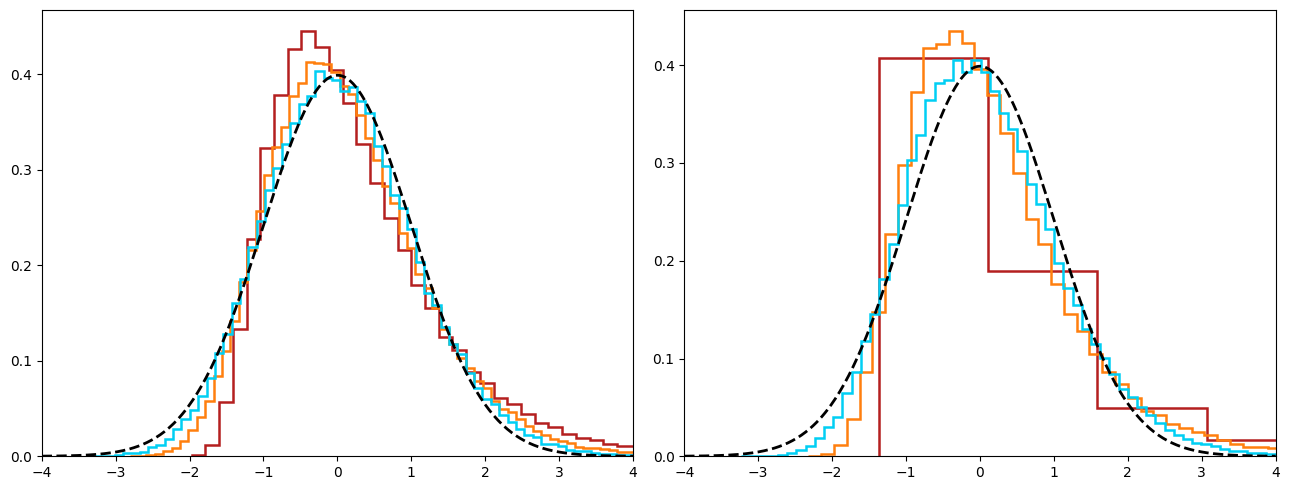

In [ ]:
"""
Delta-Method illustrations 
first-order delta method

 (0,0)  normal data,  g(x) = exp(x)
 (0,1)  skewed data,  g(x) = exp(x)

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RNG_SEED = 2024
N_SIM    = 100_000
rng      = np.random.default_rng(RNG_SEED)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- transparency ----------------------------------------------------
fig.patch.set_alpha(0.0)
for ax in axes.ravel():
    ax.patch.set_alpha(0.0)

ns     = [5, 20, 100]
# custom palette (replaces viridis): blue -> orange -> green
palette = ["#b41f1f", "#ff7f0e", "#00cff4"]
colors  = palette[:len(ns)]

xs_norm = np.linspace(-4, 4, 400)
N01_PDF = stats.norm.pdf(xs_norm)

mu, sigma = 0.0, 1.0
g  = np.exp
gp = np.exp

# ======================================================================
# Panel (0,0)  --  NORMAL data
# ======================================================================
ax = axes[0]
for n, c in zip(ns, colors):
    Xbar = rng.normal(mu, sigma / np.sqrt(n), size=N_SIM)
    T = np.sqrt(n) * (g(Xbar) - g(mu)) / (gp(mu) * sigma)
    ax.hist(T, bins=80, density=True, histtype="step",
            lw=1.8, color=c, label=f"n = {n}")

ax.plot(xs_norm, N01_PDF, "k--", lw=2, label=r"$\mathcal{N}(0,1)$")

ax.set_xlim(-4, 4)


# ======================================================================
# Panel (0,1)  --  SKEWED data, X ~ Exponential(1)
# ======================================================================
ax = axes[1]
for n, c in zip(ns, colors):
    Xbar = rng.exponential(1.0, size=(N_SIM, n)).mean(axis=1) - 1.0
    T = np.sqrt(n) * (g(Xbar) - g(mu)) / (gp(mu) * sigma)
    ax.hist(T, bins=80, density=True, histtype="step",
            lw=1.8, color=c, label=f"n = {n}")

ax.plot(xs_norm, N01_PDF, "k--", lw=2, label=r"$\mathcal{N}(0,1)$")

ax.set_xlim(-4, 4)


plt.tight_layout()
plt.savefig("delta_G_vs_Exp.png", dpi=150, transparent=True, facecolor="none")
plt.show()

/var/folders/5r/3zb78l7x2cb8py_g4z_s_c040000gn/T/ipykernel_69517/2908293388.py:39: RuntimeWarning: invalid value encountered in log1p
  T = np.log1p(Xbar)**2 / (sigma**2 / n)   # log1p(x) = log(1 + x)


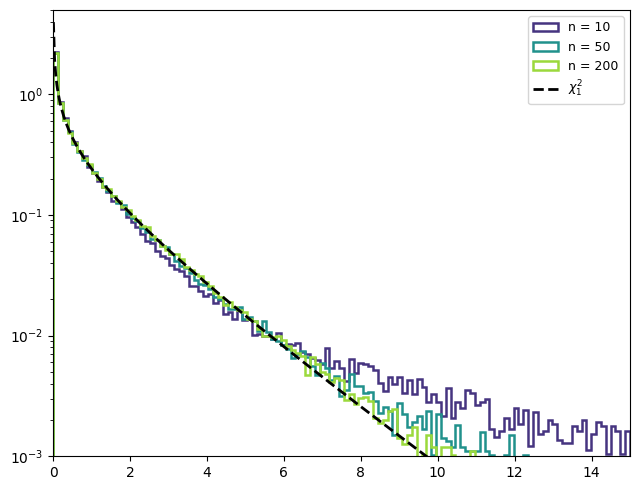

In [27]:
"""
Delta-Method illustration -- worked example.

    g(x) = log^2(1 + x) at mu = 0:
        g(0) = 0,  g'(0) = 0,  g''(0) = 2,
    so the second-order delta method gives
        log^2(1 + Xbar_n) / (sigma^2 / n)  ->  chi^2_1.

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------------------------------------------------
RNG_SEED = 2024
N_SIM    = 100_000
rng      = np.random.default_rng(RNG_SEED)

fig, ax = plt.subplots(figsize=(6.5, 5))

# ---- transparency ----------------------------------------------------
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Sample sizes and colours.
ns     = [10, 50, 200]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ns)))

# Grid and density for chi^2_1.
xs_chi2  = np.linspace(0.01, 15, 500)
CHI2_PDF = stats.chi2.pdf(xs_chi2, df=1)

sigma = 1.0


for n, c in zip(ns, colors):
    Xbar = rng.normal(0.0, sigma / np.sqrt(n), size=N_SIM)
    T = np.log1p(Xbar)**2 / (sigma**2 / n)   # log1p(x) = log(1 + x)
    ax.hist(T, bins=np.linspace(0, 15, 120), density=True,
            histtype="step", lw=1.8, color=c, label=f"n = {n}")

ax.plot(xs_chi2, CHI2_PDF, "k--", lw=2, label=r"$\chi^2_1$")
#ax.set_title(r"$\log^2(1+\bar X_n)\,/\,(\sigma^2/n) "
#             r"\rightarrow \chi^2_1$", fontsize=11)
ax.set_xlim(0, 15)
ax.set_yscale("log")
ax.set_ylim(1e-3, 5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("delta_chi.png", dpi=150, transparent=True, facecolor="none")
plt.show()